# Machine Learning Project - Password Strength Classifiers

Simone Piras 70/90/00539, Giovanni Presenti 70/90/00556, Alessia Tiddia 70/90/00501

#### Introduction 
This work aims to compare different classifiers for password strength prediction using a dataset of passwords with their respective strength labels.

#### Initial operations

In [19]:
import pandas as pd
import os

# Constants to define the number of training and testing samples
N_TRAIN = 1000
N_TEST =  100000


# Load the dataset
dirname = os.getcwd()
filename = os.path.join(dirname, "Dataset/data.csv")
data = pd.read_csv(filename, on_bad_lines="skip")
#N_TEST =  len(data) - N_TRAIN

#### Feature extraction

In [20]:
import numpy as np



data_shuffled = data.sample(frac=1)

# Ensure the 'password' column is treated as string
data_shuffled["password"] = data_shuffled["password"].astype(str)

# Extract features
pass_length_train = data_shuffled["password"].str.len().head(N_TRAIN).values
digits_train = (data_shuffled["password"].head(N_TRAIN).apply(lambda x: len([c for c in x if c.isdigit()])).values)
symbols_train = (data_shuffled["password"].head(N_TRAIN).apply(lambda x: len([c for c in x if not c.isalnum()])).values)
upper_train = (data_shuffled["password"].head(N_TRAIN).apply(lambda x: len([c for c in x if c.isupper()])).values)
lower_train = (data_shuffled["password"].head(N_TRAIN).apply(lambda x: len([c for c in x if c.islower()])).values)
unique_chars_train = data_shuffled["password"].head(N_TRAIN).apply(lambda x: len(set(x))).values

pass_length_test = data_shuffled["password"].str.len().tail(N_TEST).values
digits_test = (data_shuffled["password"].tail(N_TEST).apply(lambda x: len([c for c in x if c.isdigit()])).values)
symbols_test = (data_shuffled["password"].tail(N_TEST).apply(lambda x: len([c for c in x if not c.isalnum()])).values)
upper_test = (data_shuffled["password"].tail(N_TEST).apply(lambda x: len([c for c in x if c.isupper()])).values)
lower_test = (data_shuffled["password"].tail(N_TEST).apply(lambda x: len([c for c in x if c.islower()])).values)
unique_chars_test = data_shuffled["password"].tail(N_TEST).apply(lambda x: len(set(x))).values

# Normalize features by password length (avoid division by zero)
digits_train_norm = digits_train / np.where(pass_length_train == 0, 1, pass_length_train)
symbols_train_norm = symbols_train / np.where(pass_length_train == 0, 1, pass_length_train)
upper_train_norm = upper_train / np.where(pass_length_train == 0, 1, pass_length_train)
lower_train_norm = lower_train / np.where(pass_length_train == 0, 1, pass_length_train)
unique_ratio_train = unique_chars_train / np.where(pass_length_train == 0, 1, pass_length_train)

digits_test_norm = digits_test / np.where(pass_length_test == 0, 1, pass_length_test)
symbols_test_norm = symbols_test / np.where(pass_length_test == 0, 1, pass_length_test)
upper_test_norm = upper_test /  np.where(pass_length_test == 0, 1, pass_length_test)
lower_test_norm = lower_test /  np.where(pass_length_test == 0, 1, pass_length_test)
unique_ratio_test = unique_chars_test / np.where(pass_length_test == 0, 1, pass_length_test)





#### Test with password lenght, number of digits, number of symbols, number of uppercase, number of lowercase and number of unique characters 

In [21]:
# Split the dataset into features and target variable
xtr = np.array([pass_length_train, digits_train_norm, symbols_train_norm, upper_train_norm, lower_train_norm, unique_ratio_train]).T
ytr = data_shuffled["strength"].head(N_TRAIN).values

xts = np.array([pass_length_test, digits_test_norm, symbols_test_norm, upper_test_norm, lower_test_norm, unique_ratio_test]).T
yts = data_shuffled["strength"].tail(N_TEST).values


#### Display Train and Test subsets by password length

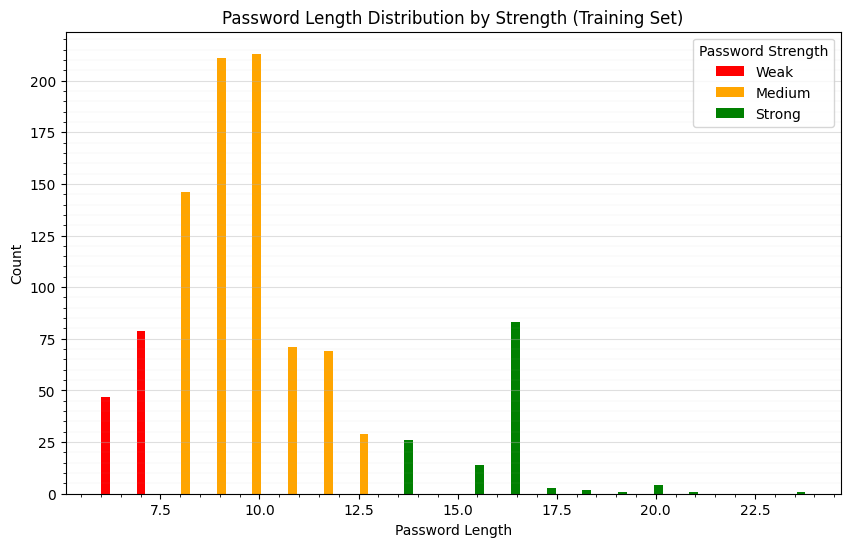

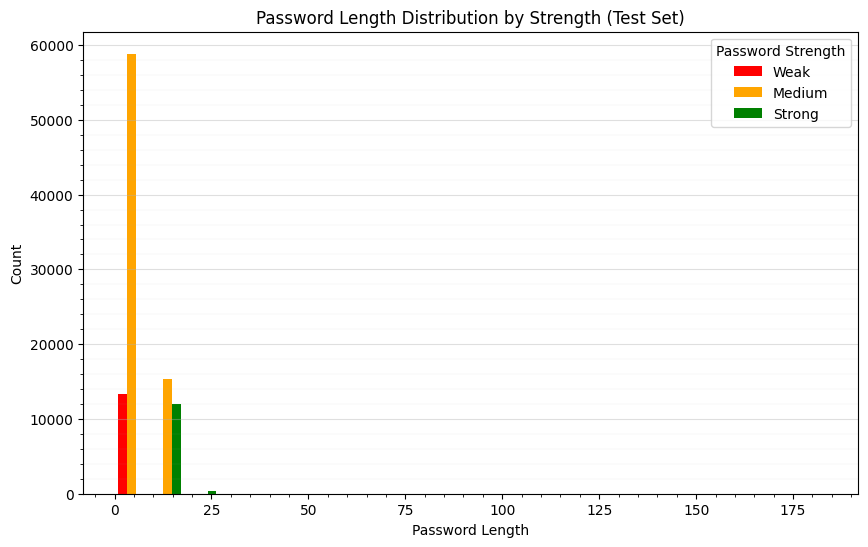

In [22]:
import matplotlib.pyplot as plt


def plot_dataset(x, y, title, bins=20):
    """
    Plots the distribution of password lengths grouped by their strength categories.
    Parameters:
        x (np.ndarray): 2D array where the first column contains password lengths.
        y (np.ndarray): 1D array of class labels corresponding to password strength for each sample in x.
        title (str, optional): Title of the plot.
        bins (int, optional): Number of bins to use for the histogram. Default is 20.
        
    Displays:
        A bar plot showing the distribution of password lengths for each strength class, with different colors and a legend.
    """
    plt.figure(figsize=(10, 6))
    classes = np.unique(y) 
    colors = ["red", "orange", "green", "blue", "purple", "cyan", "magenta"]
    all_lengths = x[:, 0]
    bin_edges = np.histogram_bin_edges(all_lengths, bins=bins)
    width = (bin_edges[1] - bin_edges[0]) / (len(classes) + 1)
    legend_names = ["Weak", "Medium", "Strong"]
    for i, k in enumerate(classes):
        lengths = x[y == k, 0]
        hist, _ = np.histogram(lengths, bins=bin_edges)
        plt.bar(
            bin_edges[:-1] + i * width,
            hist,
            width=width,
            color=colors[i % len(colors)],
            align="edge",
            label=legend_names[i],
        )

    plt.xlabel("Password Length")
    plt.ylabel("Count")
    plt.title(title)
    plt.legend(title="Password Strength")
    plt.grid(axis="y", alpha=0.4)
    plt.minorticks_on()  # Enable minor ticks
    plt.grid(which="minor", axis="y", alpha=0.2, linewidth=0.3)  # Minor grid
    plt.show()

# Plot the distributions of password lengths for training and test sets
plot_dataset(xtr, ytr, title="Password Length Distribution by Strength (Training Set)")
plot_dataset(xts, yts, title="Password Length Distribution by Strength (Test Set)")

#### Classifiers definition

In [23]:
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC

# Define the classifiers with their parameters
KNN_clf = KNeighborsClassifier(n_neighbors=5)
SVM_clf = SVC(kernel="rbf")
DT_clf = DecisionTreeClassifier(criterion="entropy", max_depth=3, random_state=0)
GNB_clf = GaussianNB()
SGD_reg = SGDClassifier(loss="hinge", penalty="l2")

# List of classifiers to be trained and tested
clfs = [KNN_clf, SVM_clf, DT_clf, GNB_clf, SGD_reg]

#### Classifiers training

In [24]:
import time

# Fit each classifier, make predictions, and evaluate performance
for clf in clfs:

    print("\n")
    print(f"---\t\t{clf.__class__.__name__}\t\t---\n")
    tic = time.perf_counter()
    clf.fit(xtr, ytr)
    toc = time.perf_counter()
    print(f"\tTraining time:\t {toc-tic:.4f} seconds")



---		KNeighborsClassifier		---

	Training time:	 0.0036 seconds


---		SVC		---

	Training time:	 0.0075 seconds


---		DecisionTreeClassifier		---

	Training time:	 0.0013 seconds


---		GaussianNB		---

	Training time:	 0.0020 seconds


---		SGDClassifier		---

	Training time:	 0.0094 seconds


#### Classifiers evaluation

	Prediction time: 5.2949 seconds
	Accuracy score:	 1.0000

              precision    recall  f1-score   support

        Weak       1.00      1.00      1.00     13387
      Medium       1.00      1.00      1.00     74168
      Strong       1.00      1.00      1.00     12445

    accuracy                           1.00    100000
   macro avg       1.00      1.00      1.00    100000
weighted avg       1.00      1.00      1.00    100000



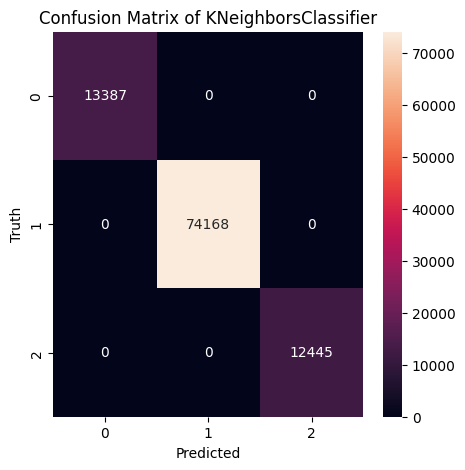

	Prediction time: 2.0361 seconds
	Accuracy score:	 1.0000

              precision    recall  f1-score   support

        Weak       1.00      1.00      1.00     13387
      Medium       1.00      1.00      1.00     74168
      Strong       1.00      1.00      1.00     12445

    accuracy                           1.00    100000
   macro avg       1.00      1.00      1.00    100000
weighted avg       1.00      1.00      1.00    100000



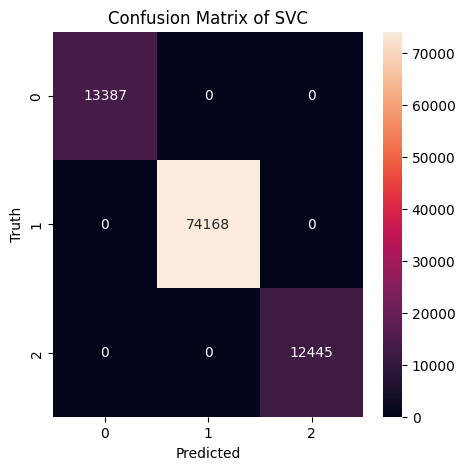

	Prediction time: 0.0070 seconds
	Accuracy score:	 1.0000

              precision    recall  f1-score   support

        Weak       1.00      1.00      1.00     13387
      Medium       1.00      1.00      1.00     74168
      Strong       1.00      1.00      1.00     12445

    accuracy                           1.00    100000
   macro avg       1.00      1.00      1.00    100000
weighted avg       1.00      1.00      1.00    100000



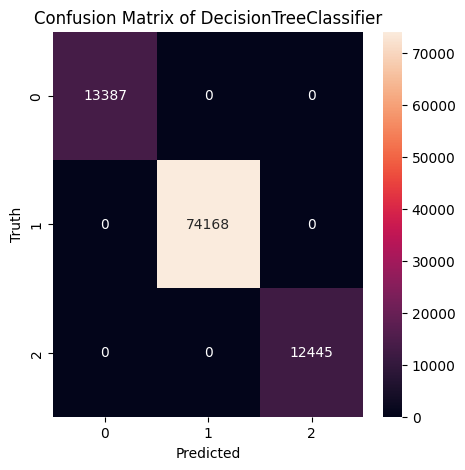

	Prediction time: 0.0258 seconds
	Accuracy score:	 0.9697

              precision    recall  f1-score   support

        Weak       1.00      0.91      0.95     13387
      Medium       0.98      0.98      0.98     74168
      Strong       0.87      0.98      0.92     12445

    accuracy                           0.97    100000
   macro avg       0.95      0.96      0.95    100000
weighted avg       0.97      0.97      0.97    100000



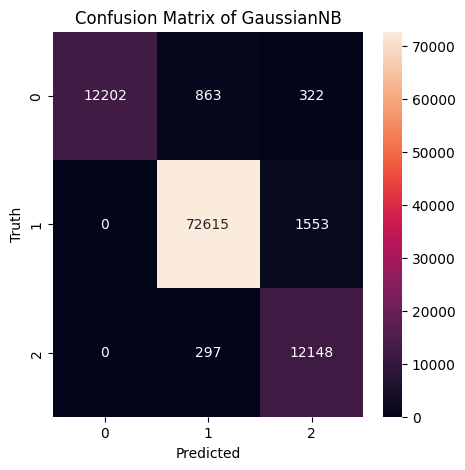

	Prediction time: 0.0067 seconds
	Accuracy score:	 0.9919

              precision    recall  f1-score   support

        Weak       1.00      0.99      1.00     13387
      Medium       0.99      1.00      0.99     74168
      Strong       1.00      0.94      0.97     12445

    accuracy                           0.99    100000
   macro avg       1.00      0.98      0.99    100000
weighted avg       0.99      0.99      0.99    100000



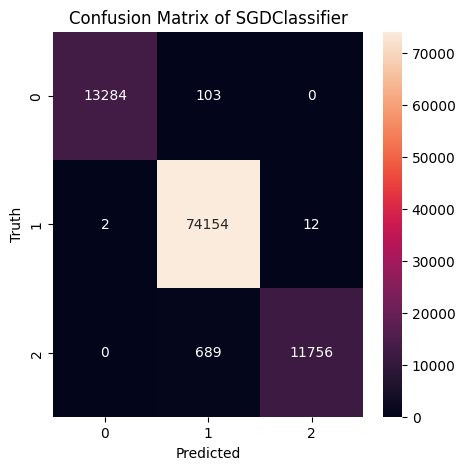

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score, classification_report


def plot_confusion_matrix(y_test, y_pred, classifier_name):
    """
    Plots the confusion matrix for a given set of true and predicted labels using a heatmap.

    Args:
        y_test (array-like): True labels of the test dataset.
        y_pred (array-like): Predicted labels from the classifier.
        classifier_name (str): Name of the classifier to display in the plot title.

    Returns:
        None: Displays the confusion matrix plot.
    """
    plt.figure(figsize=(5, 5))
    plt.title("Confusion Matrix of " + classifier_name)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d")
    plt.xlabel("Predicted")
    plt.ylabel("Truth")
    plt.show()


# Fit each classifier, make predictions, and evaluate performance
for clf in clfs:
    print("\n")
    print(f"---\t\t{clf.__class__.__name__}\t\t---\n")
    tic = time.perf_counter()
    predictions = clf.predict(xts)
    toc = time.perf_counter()
    print(f"\tPrediction time: {toc-tic:.4f} seconds")

    print(f"\tAccuracy score:\t {accuracy_score(yts, predictions):.4f}\n")
    print(classification_report(yts, predictions, target_names=["Weak", "Medium", "Strong"]))
    plot_confusion_matrix(yts, predictions, clf.__class__.__name__)
   

#### Features importance evaluation

In [ ]:
from sklearn.inspection import permutation_importance

def feature_importance_histogram(importances, feature_names=None, title=None):
    """
    Plots a histogram of feature importances.
    Parameters
    ----------
    importances: list or array-like
        The importance scores for each feature.
    feature_names: list of str, optional
        Names of the features to use as x-axis labels.
    title : str, optional
        The title of the plot.
    """
    colors = ["purple", "cyan", "lightgreen", "yellow", "black", "red", "blue", "orange"]
    n_features = len(importances)
    if feature_names is None:
        feature_names = [f"Feature {i}" for i in range(n_features)]

    plt.bar(
        range(n_features),
        importances,
        tick_label=feature_names,
        color=colors[:n_features],
        linewidth=1.2,
        alpha=0.7,
    )
    plt.xlabel("Feature")
    plt.ylabel("Importance score")
    plt.title(title)
    plt.xticks(fontsize=8, rotation=45)
    plt.show()

# Calculate and plot feature importances for each classifier
for clf in clfs:
    results = permutation_importance(clf, xts, yts, n_repeats=10, random_state=0)
    importances = results.importances_mean

    feature_names=["Length", "Digits", "Symbols", "Uppercase letters", "Lowercase letters", "Unique characters"]
    feature_importance_histogram(importances, feature_names, title=f"Features importances {clf.__class__.__name__}")

#### Tests with only Password Length as a Feature.

In [ ]:
# Split the dataset into features and target variable
xtr = np.array([(data_shuffled["password"].str.len().head(N_TRAIN).values)]).T
ytr = data_shuffled["strength"].head(N_TRAIN).values

xts = np.array([(data_shuffled["password"].str.len().tail(N_TEST).values)]).T
yts = data_shuffled["strength"].tail(N_TEST).values

for clf in clfs:

    print("\n")
    print(f"---\t\t{clf.__class__.__name__}\t\t---\n")
    tic = time.perf_counter()
    clf.fit(xtr, ytr)
    toc = time.perf_counter()
    print(f"\tTraining time:\t {toc-tic:.4f} seconds")

In [ ]:
# Fit each classifier, make predictions, and evaluate performance
for clf in clfs:

    print("\n")
    print(f"---\t\t{clf.__class__.__name__}\t\t---\n")

    tic = time.perf_counter()
    predictions = clf.predict(xts)
    toc = time.perf_counter()
    print(f"\tPrediction time: {toc-tic:.4f} seconds")

    print(f"\tAccuracy score:\t {accuracy_score(yts, predictions):.4f}\n")
    print(classification_report(yts, predictions, target_names=["Weak", "Medium", "Strong"]))
    plot_confusion_matrix(yts, predictions, clf.__class__.__name__)
    

#### Tests with Digits, Symbols, Upper, Lower and Unique characters as Features.

In [ ]:
# Split the dataset into features and target variable
xtr = np.array([digits_train_norm, symbols_train_norm, upper_train_norm, lower_train_norm, unique_chars_train]).T
ytr = data_shuffled["strength"].head(N_TRAIN).values

xts = np.array([digits_test_norm, symbols_test_norm, upper_test_norm, lower_test_norm, unique_chars_test]).T
yts = data_shuffled["strength"].tail(N_TEST).values

for clf in clfs:

    print("\n")
    print(f"---\t\t{clf.__class__.__name__}\t\t---\n")
    tic = time.perf_counter()
    clf.fit(xtr, ytr)
    toc = time.perf_counter()
    print(f"\tTraining time:\t {toc-tic:.4f} seconds")

In [ ]:
# Fit each classifier, make predictions, and evaluate performance
for clf in clfs:

    print("\n")
    print(f"---\t\t{clf.__class__.__name__}\t\t---\n")
    tic = time.perf_counter()
    predictions = clf.predict(xts)
    toc = time.perf_counter()
    print(f"\tPrediction time: {toc-tic:.4f} seconds")

    print(f"\tAccuracy score:\t {accuracy_score(yts, predictions):.4f}\n")
    print(classification_report(yts, predictions, target_names=["Weak", "Medium", "Strong"], zero_division=0))
    plot_confusion_matrix(yts, predictions, clf.__class__.__name__)



In [ ]:
# Calculate and plot feature importances for each classifier
for clf in clfs:
    results = permutation_importance(clf, xts, yts, n_repeats=10, random_state=0)
    importances = results.importances_mean
    
    feature_names=["Digits", "Symbols", "Uppercase letters", "Lowercase letters", "Unique characters"]
    feature_importance_histogram(importances, feature_names, title=f"Features importances {clf.__class__.__name__}")